# Analitica de Datos para Sitio Web E-Commerce Cafetería Cafe-Cereza #

### Etapa 6: Mecanismo analítico de diagnóstico o estimación ###

Elaborado por: <br>
1. José de Jesús Hernández Casiano
2. Michelle de la Cruz Rosalino
3. Yuleni Gayosso Martinez

Grado/Grupo: 9A IEVND <br>
<br>
**1. Importamos las librerias de Python para la manipulación y análisis de datos**

In [23]:
import pandas as pd
from prophet import Prophet
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.express as px
import datetime as dt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount("/content/drive")
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. Carga del Dataset**

Cargamos y verificamos que el Dataset se haya cargado.

In [24]:
df = pd.read_csv('/content/drive/MyDrive/BD_Cafeteria/dataset/etapa_3/dataset_ventas_limpio.csv')
df

,id_venta,id_pedido,id_cliente,nombre_cliente,correo_cliente,fecha_registro_cliente,canal_venta,categoria_producto,producto,cantidad,...,estado_pedido,metodo_pago,estado_pago,subtotal_pedido,impuestos,total_pedido,tiempo_entrega_min,calificacion_servicio,tipo_cliente,origen_ecommerce
0,1,1001,143,Estefanía Sánchez,estefanía.sánchez143@correo.com,2025-03-29,Presencial (mesero),Bebidas calientes,Té chai,3,...,entregado,tarjeta,pagado,572.34,91.57,663.91,41.0,5.0,VIP,False
1,2,1001,143,Estefanía Sánchez,estefanía.sánchez143@correo.com,2025-03-29,Presencial (mesero),Alimentos,Sandwich club,3,...,entregado,tarjeta,pagado,572.34,91.57,663.91,41.0,5.0,VIP,False
2,3,1001,143,Estefanía Sánchez,estefanía.sánchez143@correo.com,2025-03-29,Presencial (mesero),Repostería,Brownie,3,...,entregado,tarjeta,pagado,572.34,91.57,663.91,41.0,5.0,VIP,False
3,4,1001,143,Estefanía Sánchez,estefanía.sánchez143@correo.com,2025-03-29,Presencial (mesero),Café frío,Café helado,2,...,entregado,tarjeta,pagado,572.34,91.57,663.91,41.0,5.0,VIP,False
4,5,1002,206,María García,maría.garcía206@correo.com,2026-03-31,Página web,Alimentos,Panini de jamón y queso,2,...,listo,transferencia,pagado,351.54,56.25,407.79,14.0,NaN,VIP,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3749,3750,2499,82,Diego Sánchez,diego.sánchez82@correo.com,2026-04-17,Presencial (mostrador),Bebidas frías,Limonada,1,...,entregado,transferencia,pagado,21.40,3.42,24.82,33.0,5.0,VIP,False
3750,3751,2500,130,Valeria Cruz,valeria.cruz130@correo.com,2025-09-20,Página web,Alimentos,Sandwich club,3,...,entregado,pago en línea,pagado,526.12,84.18,610.30,9.0,5.0,Frecuente,True
3751,3752,2500,130,Valeria Cruz,valeria.cruz130@correo.com,2025-09-20,Página web,Bebidas calientes,Té chai,2,...,entregado,pago en línea,pagado,526.12,84.18,610.30,9.0,5.0,Frecuente,True
3752,3753,2500,130,Valeria Cruz,valeria.cruz130@correo.com,2025-09-20,Página web,Café caliente,Espresso,2,...,entregado,pago en línea,pagado,526.12,84.18,610.30,9.0,5.0,Frecuente,True


**3. Pronostico de demanda por Producto/Categoría**

Este bloque realiza la limpieza de datos, estructuración e implementación de un modelo de series de tiempo con Facebook Prophet para predecir las ventas a 30 días.

Filtrado y limpieza: Aísla únicamente los pedidos en estado entregado y convierte las fechas al formato datetime.

Agregación de datos: Suma la cantidad total vendida por día y renombra las columnas a ds (fecha) y y (métrica objetivo), adaptándolas al estándar que exige la librería Prophet.

Entrenamiento y descomposión: Ajusta el modelo activando la estacionalidad anual y semanal, genera la proyecciones para los próximos 30 días y grafica los componentes subyacentes de la serie.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


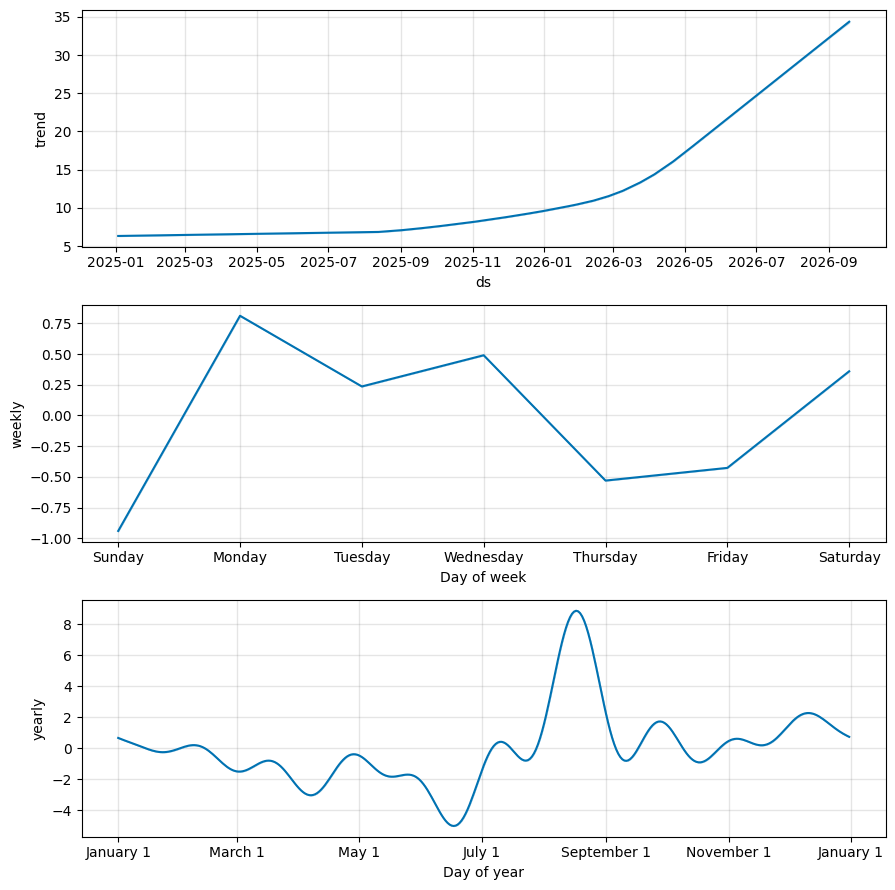

In [25]:
# Filtrar ventas válidas y convertir a datetime
df_valid = df[df['estado_pedido'] == 'entregado'].copy()
df_valid['fecha_pedido'] = pd.to_datetime(df_valid['fecha_pedido'])

# Agrupar por fecha y sumar cantidad vendida
df_prophet = (
    df_valid.groupby('fecha_pedido')['cantidad'].sum().reset_index()
)
df_prophet.columns = ['ds', 'y']

# Entrenar modelo
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(df_prophet)

# Predecir a 30 días
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
fig = model.plot_components(forecast)

**3.1. Tendencia (trend)**

*Comportamiento:* Muestra una aceleración constante a lo largo del tiempo. Durante los primeros tres trimestres de 2025 la demanda se mantuvo plana. A partir de septiembre de 2025 se observa una curva de crecimiento exponencial, proyectando superar las 30 unidades para finales de 2026.

*Diagnóstico:* El volumen base de ventas tiene un crecimiento orgánico muy saludable a largo plazo.

**3.2. Estacionalidad semanal (weekly)**

*Días con mayor volumen:* El pico más alto de la semana se registra los lunes, seguido por repuntes menores los miércoles y sábados.

*Días con menor volumen:* El domingo representa la caída más severa, mientras que jueves y viernes también se mantienen en terreno negativo.

*Diagnóstico:* El comportamiento de compra está fuertemente cargado al inicio de la semana laboral. Debido a la fuerte afluencia estudiantil entre semana.

**3.3. Estacionalidad anual (yearly)**

*Pico anual:* Ocurre de forma drástica entre finales de agosto y principios de septiembre, donde la demanda se dispara hasta casi +9 unidades por encima de la media.

*Valle del año:* Se presenta entre junio y julio, sufriendo una caída de hasta -5 unidades.

*Secundarios:* Existe un repunte moderado hacia diciembre.

*Diagnóstico:* Hay una clara estacionalidad de alta demanda al final del verano/inicio de septiembre y una desaceleración previa a mediados de año.

**4. Productos Comprados en Conjunto**

Se armo un análisis de canasta de compra usando el algoritmo Apriori para encontrar qué productos se suelen comprar juntos:

Matriz de compras: Filtra los pedidos entregados y crea una tabla indicando con True o False si el producto estuvo en la compra.

Apriori: Busca combinaciones de productos frecuentes que aparezcan al menos en el 3% de todas las ventas.

Reglas de asociación: Genera las métricas de relación y se queda solo con las parejas/grupos donde el lift sea mayor a 1.1.

Ordenamiento: Muestra la lista final ordenada de mayor a menor según el lift.

In [34]:
# Matriz booleana Ticket x Producto
basket = (
    df[df['estado_pedido'] == 'entregado']
    .groupby(['id_venta', 'producto'])['cantidad']
    .sum()
    .unstack()
    .reset_index()
    .fillna(0)
    .set_index('id_venta')
)

# Convertir a booleanos (True / False) directamente
basket_sets = basket > 0

# Algoritmo Apriori
frequent_itemsets = apriori(
    basket_sets, min_support=0.005, use_colnames=True
)
rules = association_rules(
    frequent_itemsets, metric='confidence', min_threshold=1.1
)

# Reglas ordenadas por Lift
rules_sorted = rules.sort_values(by='lift', ascending=False)[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
]

rules_sorted

,antecedents,consequents,support,confidence,lift


**5. Comparación por Horario y Día de la Semana**

Este bloque prepara y grafica un mapa de calor para identificar qué días y horas generan más ingresos con los pedidos entregados:

Extracción de fechas y horas: Convierte las fechas a datetime, obtiene el número de hora y el nombre del día de la semana.

Agregación y Pivote: Calcula el total consumido por ticket y pivotea la tabla poniendo la hora en las filas y los días en las columnas.

Visualización: Despliega la matriz con Seaborn en tonos naranja con los montos exactos grabados en cada celda.

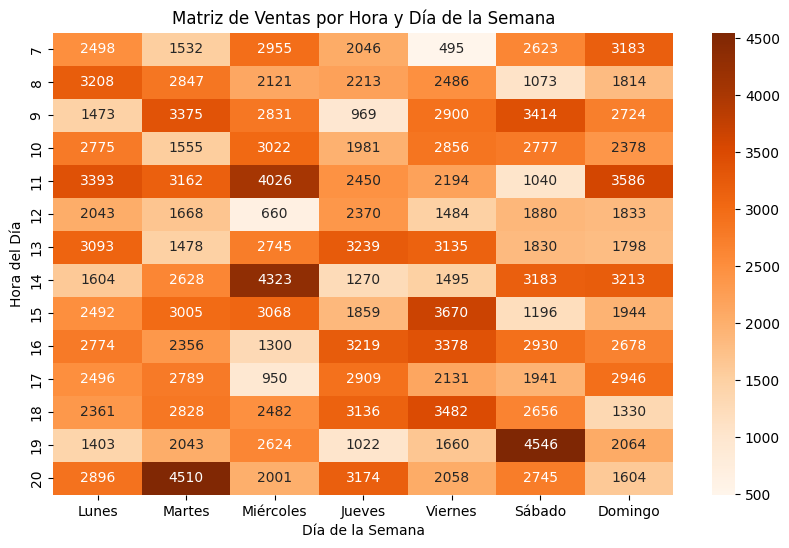

In [35]:
# 1. Filtrar y preparar fechas/horas
df_valid = df[df['estado_pedido'] == 'entregado'].copy()
df_valid['fecha_pedido'] = pd.to_datetime(df_valid['fecha_pedido'])
df_valid['hora'] = pd.to_datetime(
    df_valid['hora_pedido'], format='%H:%M:%S'
).dt.hour

# 2. Mapear días a español y definir el orden de Lunes a Domingo
dias_map = {
    'Monday': 'Lunes', 'Tuesday': 'Martes',
    'Wednesday': 'Miércoles', 'Thursday': 'Jueves',
    'Friday': 'Viernes', 'Saturday': 'Sábado',
    'Sunday': 'Domingo',
}

orden_dias = [
    'Lunes', 'Martes', 'Miércoles',
    'Jueves', 'Viernes', 'Sábado', 'Domingo',
]

# Crear la columna con categoría ordenada
df_valid['dia_semana'] = df_valid['fecha_pedido'].dt.day_name().map(dias_map)
df_valid['dia_semana'] = pd.Categorical(
    df_valid['dia_semana'], categories=orden_dias, ordered=True
)

# 3. Pivot Table usando subtotal_linea directo (evita duplicación de montos)
heatmap_data = df_valid.pivot_table(
    index='hora',
    columns='dia_semana',
    values='subtotal_linea',
    aggfunc='sum',
    fill_value=0,
    observed=False,
)

# 4. Mapa de Calor
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Oranges', annot=True, fmt='.0f')
plt.title('Matriz de Ventas por Hora y Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Hora del Día')
plt.show()

**5.1. Picos de venta**

Sábado a las 7 PM: Es la hora dorada de la semana, marcando el valor máximo de la matriz con 4,546.

Martes a las 8 PM: Sorprende con un repunte nocturno muy fuerte de 4,510.

Miércoles clave: Muestra dos picos muy marcados, uno a las 11 AM y otro a las 2 PM.

Viernes: El mejor momento es a las 3 PM con 3,670.

**5.2. Horarios muertos**

Miércoles irregular: Aunque tiene horas muy buenas, se desploma a las 12 PM y a las 5 PM.

Jueves a las 7 PM: Cae a 1,022, lo cual contrasta bastante con el pico del sábado a esa misma hora.

**6. Análisis de Estacionalidad**

Este bloque prepara la serie de tiempo a nivel diario y aplica una descomposición clásica:

   -Estructuración diaria: Filtra los pedidos entregados, los agrupa por fecha y fuerza una frecuencia diaria continua, rellenando los días sin ventas con cero para evitar huecos en la serie.

   -Descomposición aditiva: Usa seasonal_decompose con un periodo de 7 días para separar el comportamiento de las ventas en tres componentes clave: la tendencia de fondo, la estacionalidad semanal y el ruido/residuo.

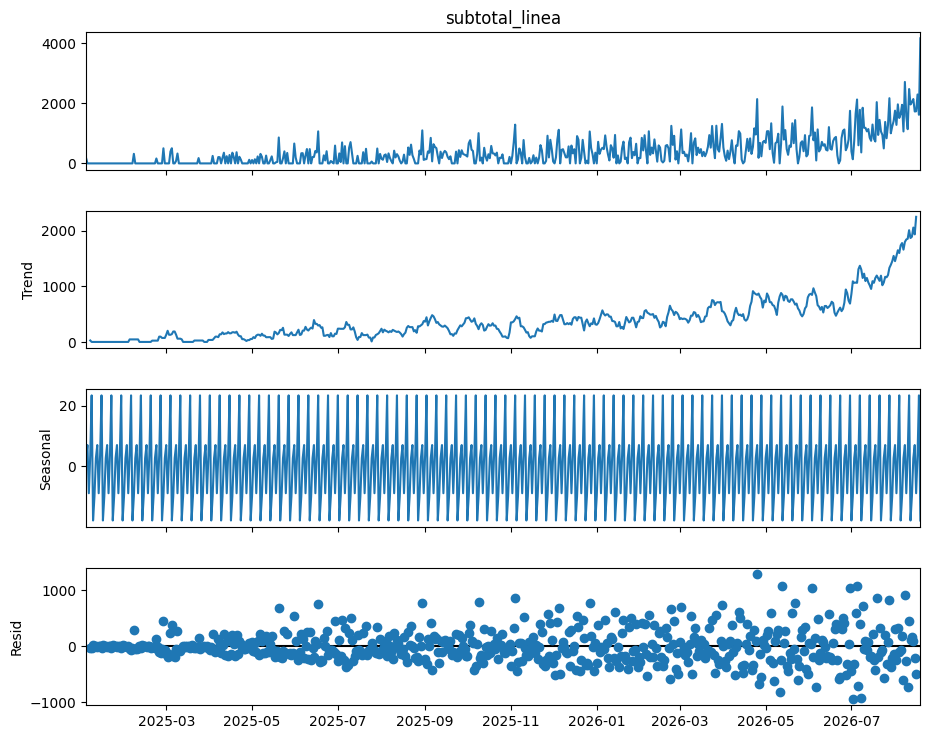

In [28]:
df_daily = (
    df[df['estado_pedido'] == 'entregado']
    .groupby(pd.to_datetime(df['fecha_pedido']))['subtotal_linea']
    .sum()
    .asfreq('D', fill_value=0)
)

decomposition = seasonal_decompose(df_daily, model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(10, 8)

**6.1. Tendencia**

Muestra un crecimiento del negocio muy claro. Durante casi todo 2025 el promedio diario fluctuaba en niveles bajos. Sin embargo, a partir de finales de 2025 y acelerando fuerte en 2026, la curva despega de forma exponencial hasta superar los 2,000 diarios.

**6.2. Estacionalidad**

Al fijar period=7, el gráfico aisla el comportamiento que se repite idéntico semana a semana. Hay un ciclo constante donde ciertos días de la semana impulsan las ventas hacia arriba y otros las hunden.

**6.3. Residuos**

Fíjate en la forma que toma la gráfica de residuos abajo: al principio los puntos están apretados cerca de 0, pero para mediados de 2026 se abren drásticamente entre -1,000 y +1,000.

**7. Rentabilidad / Volumen por Producto**

En este bloque, se agregaron:
*- Agregación por producto:* Filtra las ventas efectivamente entregadas y agrupa el catálogo por producto y categoría para calcular el volumen total, la facturación acumulada y el precio promedio.

*- Matriz Scatter 4D en Plotly:* Cruza volumen contra ingresos para mapear el rendimiento del portafolio.

*- Atributos visuales:* Asigna color por categoría de producto, ajusta el tamaño de la burbuja según el precio unitario y coloca el nombre del producto como etiqueta flotante.

In [29]:
df_prod = (
    df[df['estado_pedido'] == 'entregado']
    .groupby(['producto', 'categoria_producto'])
    .agg(
        unidades_vendidas=('cantidad', 'sum'),
        ingreso_total=('subtotal_linea', 'sum'),
        precio_promedio=('precio_unitario', 'mean'),
    )
    .reset_index()
)

fig = px.scatter(
    df_prod,
    x='unidades_vendidas',
    y='ingreso_total',
    color='categoria_producto',
    size='precio_promedio',
    text='producto',
    title='Matriz de Volumen de Ventas vs. Ingresos por Producto',
    labels={
        'unidades_vendidas': 'Cantidad Vendida',
        'ingreso_total': 'Ingreso Total ($)',
    },
)
fig.update_traces(textposition='top center')
fig.show()

**Productos estrella**

*Sandwich club:* Es el líder indiscutible del negocio. Combina una rotación altísima con un precio elevado, alcanzando casi los $18,000 en facturación.

*Alimentos pesados:* La categoría Alimentos es el motor financiero de la tienda. Tienen un ticket promedio alto que empuja la facturación arriba de los $13,000 - $15,000.

*Frappé de café:* Es el producto individual más vendido en volumen, aportando $13,000 sólidos a la caja.

**Productos de volumen pero menor ticket**

*Chocolate caliente:* Se vende muchísimo, pero al tener un precio unitario más bajo, sus ingresos se quedan cerca de los $8,500.

*Cold Brew y Frappuccino de caramelo:* Tienen excelente tracción con facturación equilibrada en el rango de los $10,500 - $11,000.

**Zona rezagada**

*Repostería y café básico:* Tienen baja rotación e ingresos bajos. Funcionan como venta cruzada o gancho, pero no sostienen el negocio.

*Bebidas frías simples:* Son los productos con menor facturación global.

**Oportunidad de mejora visual**

Hay encimamiento de etiquetas en el centro. Para reportes ejecutivos te conviene retirar el parámetro text='producto' y dejar que la interactividad del hover de Plotly haga el trabajo limpio.

**8. Segmentación RFM de Clientes**

Este bloque implementa una segmentación de clientes basada en el modelo RFM combinada con aprendizaje no supervisado:

*Cálculo de métricas RFM:* Filtra ventas válidas y calcula para cada cliente cuánto tiempo tiene sin comprar, cuántos pedidos distintos ha hecho y cuánto ha gastado en total.

*Estandarización:* Aplica StandardScaler para normalizar las tres variables a una misma escala. Esto es crucial para que el peso del Monto no opaque a la Frecuencia o la Recencia al calcular distancias en K-Means.

*Agrupamiento K-Means:* Divide a los clientes en 3 clústeres o perfiles bien definidos y muestra el promedio de cada métrica por grupo.

In [30]:
df_valid = df[df['estado_pedido'] == 'entregado'].copy()
df_valid['fecha_pedido'] = pd.to_datetime(df_valid['fecha_pedido'])

fecha_referencia = df_valid['fecha_pedido'].max() + dt.timedelta(days=1)

# Agrupación RFM por id_cliente
rfm = df_valid.groupby('id_cliente').agg(
    Recencia=('fecha_pedido', lambda x: (fecha_referencia - x.max()).days),
    Frecuencia=('id_venta', 'nunique'),
    Monto=('subtotal_linea', 'sum'),
)

# Escalamiento y Clustering K-Means
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.groupby('Cluster').mean())

           Recencia  Frecuencia        Monto
Cluster                                     
0         34.881356    8.491525   767.771186
1        182.062500    5.916667   545.279167
2         48.292683   16.109756  1473.576220


**Conclusiones**

El recorrido realizado a lo largo del notebook integra proyecciones de demanda, patrones de consumo y segmentación de clientes, ofreciendo una radiografía clara del estado actual y las oportunidades de escalabilidad del negocio. <br>
*Salud y proyección de la demanda:* Las métricas temporales revelan que la empresa está experimentando una aceleración sólida y exponencial. La proyección generada a 30 días mediante Facebook Prophet confirma una tendencia al alza que superará los $30$ pedidos diarios hacia el cierre del periodo proyectado. Adicionalmente, la descomposición de la serie demuestra que esta demanda no es homogénea: existen estacionalidades semanales fuertemente marcadas a inicios de semana y picos anuales clave que exigen una planificación logística previa para evitar desabastos. <br>
*Comportamiento operativo y rotación de productos:* El mapa de calor de ventas identificó con precisión las "horas doradas" de operación, permitiendo optimizar los turnos de personal y la preparación de inventario en cocina. Por su parte, la matriz de volumen e ingresos dejó en claro que la categoría de Alimentos y las bebidas preparadas representan los pilares financieros del negocio, al combinar una alta rotación con márgenes sustanciales. <br>
*Valor del cliente y accionabilidad (RFM):* Finalmente, la segmentación mediante K-Means aportó el pilar estratégico del análisis. Identificar que el Cluster 2 sostiene el mayor valor de vida del cliente permite blindar a ese segmento mediante programas de fidelización. A su vez, conocer que el Cluster 1 lleva cerca de 6 meses inactivo facilita la creación de campañas de reactivación dirigidas sin malgastar presupuesto de marketing en audiencias de bajo retorno. <br><br>
En síntesis, los modelos aplicados demuestran un negocio con tracción en fase de expansión. Las áreas prioritarias de acción inmediata deben ser: ajustar la capacidad operativa para los días de mayor tráfico, reforzar la venta cruzada entre la repostería de baja rotación y los productos estrella de alimentos, y ejecutar estrategias diferenciadas de retención según el perfil de cada cliente.